# $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

import dependencies

In [2]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
# import odesolver
import numpy as np
import itertools
import functools
import tqdm
import networkx as nx

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FFMpegWriter
from jax.extend.backend import get_backend


print(jax.devices())

print(f"JAX is using: {get_backend().platform}")

[CudaDevice(id=0)]
JAX is using: gpu


## Utils

### lattice visulizers

1D

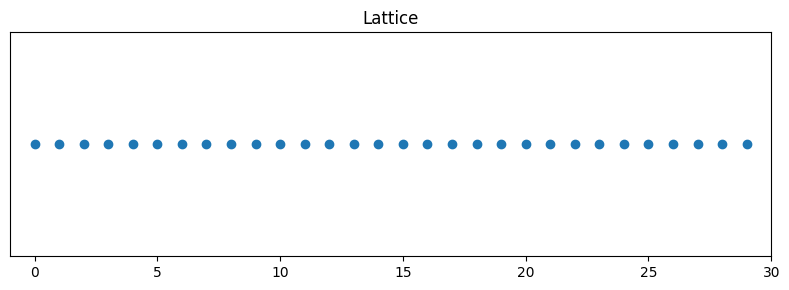

In [3]:
def visualize_lattice_1d(lengths, d):
    dim = len(lengths)
    assert dim == 1
    
    n = lengths[0]
    plt.figure(figsize=(8, 3))
    points_x = d * np.arange(n)
    points_y = np.zeros_like(points_x)
    plt.title("Lattice")
    plt.xlim((-d, d * n))
    plt.scatter(points_x, points_y)
    plt.gca().axes.yaxis.set_visible(False)
    plt.tight_layout()
    plt.show()
    
lengths = [30]
dim = len(lengths)
d = 1

visualize_lattice_1d(lengths, d)

2D

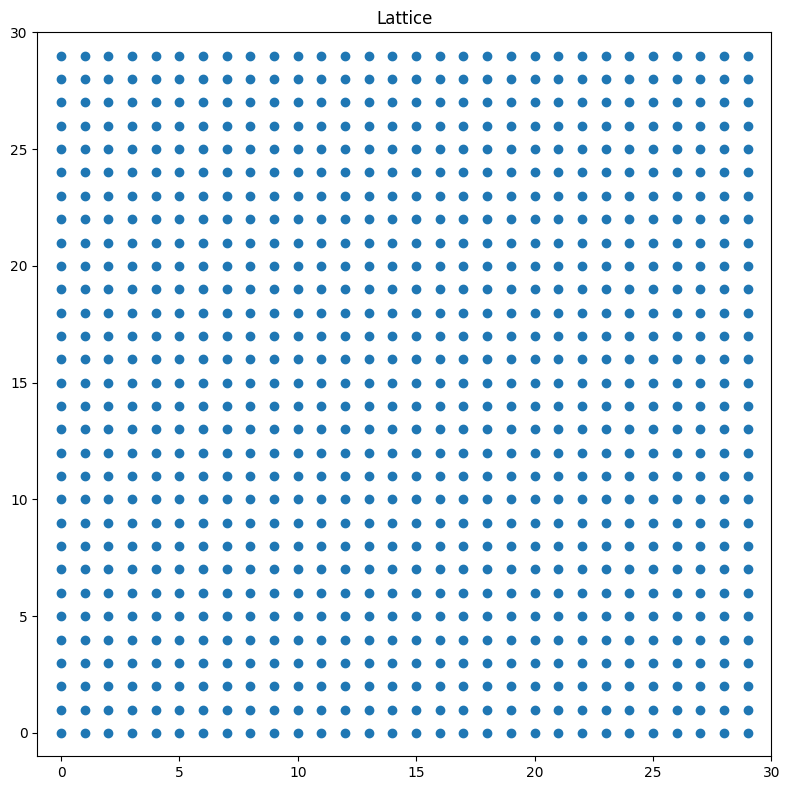

In [4]:
def visualize_lattice_2d(lengths, d, figsize=None):
    dim = len(lengths)
    assert dim == 2
    
    nx, ny = lengths
    
    
    figsize = figsize or (8 * np.sqrt(nx / ny), 8 * np.sqrt(ny / nx))
    
    plt.figure(figsize=figsize)
    
    points_x, points_y = d * np.array(list(itertools.product(range(nx), range(ny)))).T
    
    plt.title("Lattice")
    plt.xlim((-d, d * nx))
    plt.ylim((-d, d * ny))
    plt.scatter(points_x, points_y)
    plt.tight_layout()
    plt.show()
    
lengths = [30, 30]
dim = len(lengths)
d = 1

visualize_lattice_2d(lengths, d)

3D

In [5]:
def visualize_lattice_3d(lengths, dim, d):
    pass
    
lengths = [6, 6, 6]
dim = len(lengths)
d = 1

visualize_lattice_3d(lengths, dim, d)

### Lattice momentum visualizers

In [6]:
match dim:
    case 1:
        n = lengths[0]
        plt.figure(figsize=(8, 3))
        points_x = d * np.arange(n)
        points_y = np.zeros_like(points_x)
        plt.title("Lattice")
        plt.xlim((-d, d * n))
        plt.scatter(points_x, points_y)
        plt.gca().axes.yaxis.set_visible(False)
        plt.tight_layout()
        plt.show()
        
    case 2:
        # k1, k2 = momentum_arr.T
        # plt.figure(figsize=(8, 8))
        # plt.quiver(
        #     np.zeros_like(k1),
        #     np.zeros_like(k2),
        #     k1, k2,
        #     angles="xy", scale_units="xy", scale=1, color="b"
        # )
        # plt.xlim(-1.1 * np.pi / d, 1.1 * np.pi / d)
        # plt.ylim(-1.1 * np.pi / d, 1.1 * np.pi / d)
        # plt.gca().set_aspect("equal")
        # plt.grid(True)
        # plt.show()
        pass
    case 3:
        pass
    case x if x > 3:
        print(f"can not visualize {x}-dimensional lattice ")
    case x:
        print(f"invalid dimension: {x}")

### Handling multi-particle states

In [7]:
def format_size(size_in_bytes):
    """
    Convert a size in bytes to a human-readable string with units B, KB, MB, or GB.

    Args:
        size_in_bytes (int): Size in bytes. Must be non-negative.

    Returns:
        str: Formatted size with appropriate unit.

    Raises:
        ValueError: If size_in_bytes is negative.

    Examples:
        >>> format_size(123)
        '123.00 B'
        >>> format_size(1024)
        '1.00 KB'
        >>> format_size(1048576)
        '1.00 MB'
        >>> format_size(1073741824)
        '1.00 GB'
        >>> format_size(2**40)
        '1024.00 GB'
    """
    if size_in_bytes < 0:
        raise ValueError("Size must be non-negative")

    units = ["B", "KB", "MB", "GB"]
    unit_index = 0

    # Keep dividing by 1024 to find the appropriate unit, but stop at GB
    while size_in_bytes >= 1024 and unit_index < len(units) - 1:
        size_in_bytes /= 1024
        unit_index += 1

    # Format the number to two decimal places
    return f"{size_in_bytes:.2f} {units[unit_index]}"

`get_sites_multi_indices`: Return multi-indices tuple of sites. sorted by lexicographic order.

`get_single_particle_states`: Return single particle states including spin states $\ket{\mathbf{r}_i, 
\sigma}$ as a tuple (site multi-index, $\sigma$). sorted by lexicographic order.

`get_multi_particle_states`: Return combination of single particle states. each state is sorted by lexicographic order $c_{\sigma_1}^\dagger(\mathbf{r}_1)\cdots c_{\sigma_n}^\dagger(\mathbf{r}_N)\ket{0}$

In [8]:
def get_sites_multi_indices(lengths):
    return list(itertools.product(*map(range, lengths)))

lengths = [30, 30]
sites_multi_indices = get_sites_multi_indices(lengths)
sites_multi_indices[:5]

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]

In [9]:
def get_single_particle_states(lengths):
    sites_multi_indices = get_sites_multi_indices(lengths)
    return [(x, s) for x in sites_multi_indices for s in [1, -1]]

lengths = [30, 30]
single_particle_states = get_single_particle_states(lengths)
single_particle_states[:5]

[((0, 0), 1), ((0, 0), -1), ((0, 1), 1), ((0, 1), -1), ((0, 2), 1)]

In [10]:
def get_multi_particle_states(lengths, num_particles):
    single_particle_states = get_single_particle_states(lengths)
    return list(itertools.combinations(single_particle_states, num_particles))
    # return list(itertools.combinations_with_replacement(single_particle_states, num_particles))

num_particles = 2
lengths = [30, 30]
multi_particle_states = get_multi_particle_states(lengths, num_particles)
multi_particle_states[:5]

[(((0, 0), 1), ((0, 0), -1)),
 (((0, 0), 1), ((0, 1), 1)),
 (((0, 0), 1), ((0, 1), -1)),
 (((0, 0), 1), ((0, 2), 1)),
 (((0, 0), 1), ((0, 2), -1))]

In [11]:
def print_multi_particle_states_info(multi_particle_states):
    num_particles = len(multi_particle_states[0])
    print(f"{len(multi_particle_states)} {num_particles}-particle states")
    print(f"{format_size(len(multi_particle_states) * 16)} per state (complex128)")
    print(f"{format_size((len(multi_particle_states) ** 2) * 16)} for dense representation of an operator (complex128)")
    
print_multi_particle_states_info(multi_particle_states)

1619100 2-particle states
24.71 MB per state (complex128)
39063.17 GB for dense representation of an operator (complex128)


In [12]:
def create_index_map(elements):
    return {element: idx for idx, element in enumerate(elements)}

site_to_index_map = create_index_map(sites_multi_indices)
state_to_index_map_single = create_index_map(single_particle_states)
state_to_index_map_multi = create_index_map(multi_particle_states)

In [13]:
def add_multi_index(midx1, midx2):
    return tuple((idx1 + idx2) % length for idx1, idx2, length in zip(midx1, midx2, lengths))

def substract_multi_index(midx1, midx2):
    return tuple((idx1 + idx2) % length for idx1, idx2, length in zip(midx1, midx2, lengths))

def get_opposite(midx):
    return tuple((-idx) % length for idx, length in zip(midx, lengths))

In [14]:
def order(lhs, rhs):
    site_index1, spin1 = lhs
    site_index2, spin2 = rhs
    
    if site_index1 < site_index2:
        return True
    elif site_index1 == site_index2:
        return spin1 > spin2
    return False

key_func = functools.cmp_to_key(order)
assert multi_particle_states == [tuple(sorted(multi_particle_state, key=key_func)) for multi_particle_state in multi_particle_states]

In [15]:
def sorted_multi_particle_state(multi_particle_state):
    """return sorted multi_particle_state as tuple and parity of swap count
    partiy = 1 if sorted list is even permutation of original list.
    parity = -1 if it is odd permutation.
    parity = 0 if it cannot be determined. (there exists a pair of identical element.)
    """
    lst = list(multi_particle_state)
    n_particles = len(lst)
    parity = 1
    for i in range(n_particles):
        swapped = False
        for j in range(0, n_particles - i - 1):
            if lst[j] == lst[j + 1]:
                parity = 0
                continue
            if not order(lst[j], lst[j + 1]):
                lst[j], lst[j + 1] = lst[j + 1], lst[j]
                swapped = True
                parity *= -1
        if not swapped:
            break
    return tuple(lst), parity

In [16]:
def get_position_arr(lengths, d):
    sites_multi_indices = get_sites_multi_indices(lengths)
    position_arr = d * jnp.array(sites_multi_indices, dtype=jnp.float64)
    return list(position_arr)

lengths = [30, 30]
d = 1
positions = get_position_arr(lengths, d)

positions[:5]

[Array([0., 0.], dtype=float64),
 Array([0., 1.], dtype=float64),
 Array([0., 2.], dtype=float64),
 Array([0., 3.], dtype=float64),
 Array([0., 4.], dtype=float64)]

In [17]:
def get_momentum_arr(lengths, d):
    sites_multi_indices = get_sites_multi_indices(lengths)
    site_index_arr = d * jnp.array(sites_multi_indices, dtype=jnp.float64)
    
    k0 = 2 * jnp.pi / (d * jnp.array(lengths))
    momentum_arr = site_index_arr * k0
    momentum_arr = jnp.where(momentum_arr > jnp.pi / d, 
                             momentum_arr - 2 * jnp.pi / d, 
                             momentum_arr)
    return list(momentum_arr)
    
lengths = [30, 30]
d = 1
momentums = get_momentum_arr(lengths, d)
momentums[:5]

[Array([0., 0.], dtype=float64),
 Array([0.        , 0.20943951], dtype=float64),
 Array([0.        , 0.41887902], dtype=float64),
 Array([0.        , 0.62831853], dtype=float64),
 Array([0.        , 0.83775804], dtype=float64)]

### Fourier transformations

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

## Solving ODE

### utils

 ### Defining Operators and Getting Matrix Representation


- hamiltonian

$$
\begin{align}
    H&=\sum_{\mathbf{k}}[t_{\uparrow\uparrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\uparrow\downarrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})+t_{\downarrow\uparrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\downarrow\downarrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})]-i\frac{\gamma}{2}\sum_{\mathbf{r}}n_\uparrow(\mathbf{r}) n_\downarrow(\mathbf{r}) \\
    &=\underbrace{\sum_{\mathbf{k}}\left[\varepsilon_1(\mathbf{k})c_1^\dagger(\mathbf{k})c_1(\mathbf{k}) + \varepsilon_2(\mathbf{k})c_2^\dagger(\mathbf{k})c_2(\mathbf{k})\right]}_{H_0} + \underbrace{\frac{-1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')}_{V_\text{loss}}
\end{align}

$$

$$t_{\uparrow\uparrow}=\frac{\hbar^2(k-q)^2}{2m_\mathrm{Yb}}+\frac{\delta}{2},\quad t_{\uparrow\downarrow}= t_{\downarrow\uparrow}=\frac{\Omega_R}{2},\quad t_{\downarrow\downarrow}=\frac{\hbar^2(k+q)^2}{2m_\mathrm{Yb}}-\frac{\delta}{2}$$

- number operators

$$n_\sigma = c_\sigma^\dagger(\mathbf{k})c_\sigma(\mathbf{k}), \quad \sigma=\uparrow,\downarrow$$
$$n_m = c_m^\dagger(\mathbf{k})c_m(\mathbf{k}), \quad m=1, 2$$

$$
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_1(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & \beta(\mathbf{k}) \\
    -\beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix},\quad
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & -\beta(\mathbf{k}) \\
    \beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_1(\mathbf{k})
\end{pmatrix}
$$
$\alpha$ and $\beta$ are real and $\alpha^2+\beta^2=1$


- fourier transforms

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

lattice parameters

In [18]:
d = 1.
lengths = [10]
dim = len(lengths)
k0 = 2 * jnp.pi / (d * jnp.array(lengths))

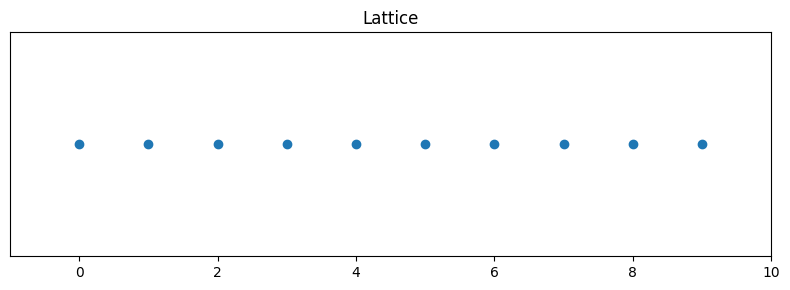

In [19]:
visualize_lattice_1d(lengths, 1)

In [20]:
num_particles = 4

sites_multi_indices = get_sites_multi_indices(lengths)
single_particle_states = get_single_particle_states(lengths)
multi_particle_states = get_multi_particle_states(lengths, num_particles)

num_sites = len(sites_multi_indices)
num_single_particle_states = len(single_particle_states)
num_multi_particle_states = len(multi_particle_states)

site_to_index_map = create_index_map(sites_multi_indices)
state_to_index_map_single = create_index_map(single_particle_states)
state_to_index_map_multi = create_index_map(multi_particle_states)

print_multi_particle_states_info(multi_particle_states)

positions = get_position_arr(lengths, d)
momentums = get_momentum_arr(lengths, d)

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


constants

In [21]:
hbar = 1
q = 0.04 * k0
m_Yb = 1
delta = 0.08
omega_R = 0.2
gamma = 0.1

In [55]:
@jax.jit
def kinetic(k):
    t = jnp.array([
        [(hbar ** 2) * jnp.sum((k - q) ** 2) / (2 * m_Yb) + delta / 2, omega_R / 2],
        [omega_R / 2, (hbar ** 2) * jnp.sum((k + q) ** 2) / (2 * m_Yb) - delta / 2]
    ])
    return jax.device_put(t, device=jax.devices("cpu")[0])

def e1(k):
    pass

def e2(k):
    pass

def alpha(k):
    pass

def beta(k):
    pass

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [59]:
%load_ext line_profiler

# @jax.jit
def hamiltonian():
    space_dim = len(multi_particle_states)
    
    hamiltonian = np.zeros((space_dim, space_dim), np.complex128)
    
    # kinetic term
    for state_index, multi_particle_state in tqdm.tqdm(list(enumerate(multi_particle_states))):
        num_particles = len(multi_particle_state)
        iterator = iter(range(num_particles))
        
        for i in iterator:
            momentum_idx, spin = multi_particle_state[i]
            momentum = momentums[site_to_index_map[momentum_idx]]
            t = np.array(kinetic(momentum))

            if (i + 1 < num_particles) and (momentum_idx == multi_particle_state[i + 1][0]):
                # state contain c_up(k), c_down(k) both
                hamiltonian[state_index, state_index] += t.trace()

                next(iterator, None)
            else:
                # state contain c_up(k) xor c_down(k)
                spin_changed = list(multi_particle_state)  # copy state
                spin_changed[i] = (momentum_idx, -spin)     # reflect spin
                spin_changed_tuple = tuple(spin_changed)
                spin_changed_index = state_to_index_map_multi[spin_changed_tuple]
                
                spin_idx = (1 - spin) // 2  # \sigma = 1 -> 0, \sigma -1 -> 1

                hamiltonian[state_index, state_index] += t[spin_idx, spin_idx]
                hamiltonian[spin_changed_index, state_index] += t[1 - spin_idx, spin_idx]
                   
    # interaction term
    U = -1j * gamma / 2
    for state_index, multi_particle_state in tqdm.tqdm(list(enumerate(multi_particle_states))):
        spin_up_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == 1]
        spin_down_states = [(idx, single[0]) for idx, single in enumerate(multi_particle_state) if single[1] == -1]

        for spin_up_state, spin_down_state in itertools.product(spin_up_states, spin_down_states):
            idx1, momentum_1_idx_i = spin_up_state
            idx2, momentum_2_idx_i = spin_down_state

            for q_idx in sites_multi_indices:
                momentum_1_idx_f = add_multi_index(momentum_1_idx_i, q_idx)
                momentum_2_idx_f = substract_multi_index(momentum_2_idx_i, q_idx)
                new_multi_particle_state = list(multi_particle_state)
                new_multi_particle_state[idx1] = (momentum_1_idx_f, 1)
                new_multi_particle_state[idx2] = (momentum_2_idx_f, -1)
                new_multi_particle_state, parity = sorted_multi_particle_state(new_multi_particle_state)
                if parity == 0:
                    continue
                new_idx = state_to_index_map_multi[new_multi_particle_state]
                hamiltonian[new_idx, state_index] += parity * U / num_sites
        
    return jnp.array(hamiltonian)
        
    
def sparse_hamiltonian():
    space_dim = len(multi_particle_states)
    
    hamiltonian = np.zeros((space_dim, space_dim))
    
    
# %lprun -f hamiltonian H_dense = hamiltonian()
H_dense = hamiltonian()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


100%|██████████| 4845/4845 [00:00<00:00, 15419.66it/s]


### others

$$ n_\uparrow(\mathbf{k}), n_\downarrow(\mathbf{k})

In [24]:
def __number_operator_spin(vec, momentum_index, spin):
    pass

number_operator_spin = {}

$$ n_1(\mathbf{k}), n_2(\mathbf{k})

In [25]:
def __number_operator_1(vec, momentum_index):
    pass

def __number_operator_2(vec, momentum_index):
    pass

number_operator_bare_states = {}

$$\braket{n_\uparrow(\mathbf{k})}, \braket{n_\downarrow(\mathbf{k})}$$

In [26]:
def __number_operator_spin_expectation(vec, momentum_index, spin):
    pass

number_operator_spin_expectation = {}

$$\braket{n_1(\mathbf{k})}, \braket{n_2(\mathbf{k})}$$

In [27]:
def __number_operator_bare_expectation(vec, momentum_index, spin):
    pass

number_operator_bare_expectation = {}

### Setting initial state

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

In [28]:
def get_state_vector_from_momentum(single_particle_states):
    """single particle state |k, s>들을 list of tuple [(i_k, s) ...] 형태로 받아 one-hot vector를 반환합니다. 
    k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
    Args:
        single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

    Returns:
        jax.Array: one-hot vector
    
    """
    assert len(single_particle_states) == num_particles
    space_dim = len(multi_particle_states)
    multi_particle_state, parity = sorted_multi_particle_state(single_particle_states)
    assert parity != 0
    idx = state_to_index_map_multi[multi_particle_state]
    zero_vector = jnp.zeros((space_dim,), dtype=jnp.complex128)
    one_hot = zero_vector.at(idx).set(parity)
    return parity * one_hot

def get_state_vector_from_position(single_particle_states):
    """single particle state |r_i, s>들을 list of tuple [(i, s) ...] 형태로 받아 하나의 vector를 반환합니다. 
    i는 multi-index, r_i는 particle의 위치, s는 Pauli-z operator의 eigenvalue
    
    Args:
        single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.

    Returns:
        jax.Array: one-hot vector
    
    """
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=jnp.complex128)
    
    for permutation in itertools.permutations(len(num_sites), n):
        pass
    
    multi_particle_state, parity = sorted_multi_particle_state(single_particle_states)
    assert parity != 0
    idx = state_to_index_map_multi[multi_particle_state]
    
    one_hot = zero_vector.at(idx).set(1)
    return jnp.array(one_hot)

def get_bare_state(single_particle_states, state_to_index_map_multi=state_to_index_map_multi, space_dim=len(multi_particle_states)):
    """single particle state들 |k, m>를 tuple (i_k, m) 형태로 받아 vector를 반환합니다. 
    k는 lattice momentum vector, i_k는 k에 부여된 multi-index s는 Pauli-z operator의 eigenvalue
    
    Args:
        single_particle_states (list[tuple[tuple[int, int, ..., int], int]]): single particle states, 순서는 무시되며 lexicographic order로 정렬됨됨.
        state_to_index_map_multi
        space_dim

    Returns:
        jax.Array: one-hot vector
    
    """    
    vector = jnp.zeros((space_dim,))
    n_particles = len(single_particle_states)
    z = [1, -1]
    for zs in itertools.product(z, repeat=n_particles):
        vector = vector + 0 # TODO: determine the coefficients
        
    return vector
    
    

### Numerically integrating Schrodinger's equation

$$\frac{d}{dt}\ket{\psi}=-\frac{i}{\hbar}H\ket{\psi}$$

In [29]:
# params
t0 = 0
n_steps = 10000
step_size = 1e-4

In [30]:
def f(vec):
    return -(1j / hbar) * (H_dense @ vec)

initial_state = 
solution = odesolver.solve_ivp(f, t0, initial_state, n_steps, step_size=step_size)

SyntaxError: invalid syntax (466243938.py, line 4)

### plotting results

## ED

In [ ]:
def num_momentum_diag(momentum_multi_index, spin):
    # return diagonal elements of momentum-space number operator
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for index, multi_particle_state in enumerate(multi_particle_states):
        if (momentum_multi_index, spin) in multi_particle_state:
            zero_vector[index] = 1
    return jnp.array(zero_vector)
    
def num_cooper_pairs_diag():
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_op = get_opposite(momentum_midx)
        n1 = num_momentum_diag(momentum_midx, 1)
        n2 = num_momentum_diag(momentum_midx_op, -1)
        zero_vector += n1 * n2
    return jnp.array(zero_vector)

def correlator_diag():
    space_dim = len(multi_particle_states)
    zero_vector = np.zeros((space_dim,), dtype=np.complex128)
    for momentum_midx in sites_multi_indices:
        momentum_midx_op = get_opposite(momentum_midx)
        n1 = num_momentum_diag(momentum_midx, 1)
        n2 = num_momentum_diag(momentum_midx_op, -1)
        zero_vector += 1 - n1 - n2 + n1 * n2
    return jnp.array(zero_vector)

from scipy.special import binom

jnp.sum(num_momentum_diag((0, ), 1)), binom(num_single_particle_states - 1, num_particles - 1)

(Array(969.+0.j, dtype=complex128), np.float64(969.0))

In [ ]:
eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)
eigenvalues

Array([16.43360425-0.01790416j, 15.94098719-0.01790511j,
       16.1872358 -0.02499932j, ...,  5.91974381-0.01754725j,
        5.92136683-0.01623648j,  5.92267457-0.01570522j],      dtype=complex128)

In [ ]:
jnp.sum(jnp.abs(jnp.linalg.norm(eigenvectors, axis=0) - 1)) # normalized

Array(3.29514194e-13, dtype=float64)

In [ ]:
E_r = jnp.real(eigenvalues)
E_i = jnp.imag(eigenvalues)

In [ ]:
min_E_r_idx = jnp.argmin(E_r)
min_E_r = E_r[min_E_r_idx]


min_E_i_idx = jnp.argmin(E_i)
min_E_i = E_i[min_E_i_idx]


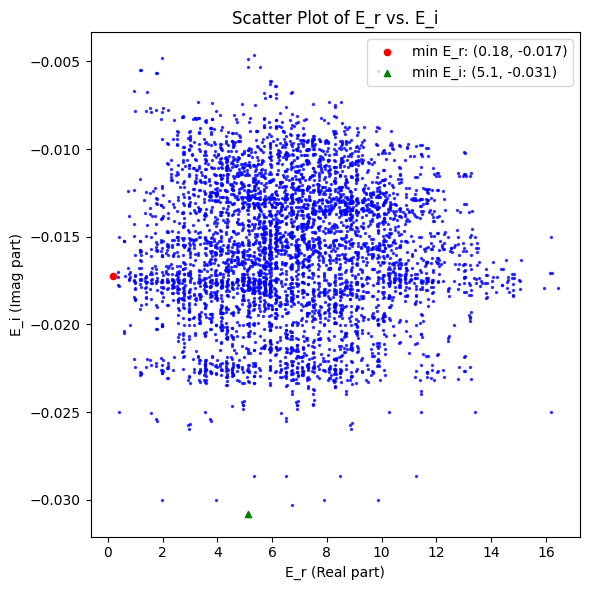

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(E_r, E_i, color='blue', alpha=0.7, s=2)

plt.xlabel("E_r (Real part)")
plt.ylabel("E_i (Imag part)")
plt.title("Scatter Plot of E_r vs. E_i")

plt.scatter(E_r[min_E_r_idx], E_i[min_E_r_idx],
            color='red', s=20, marker='o',
            label=f'min E_r: ({E_r[min_E_r_idx]:.2}, {E_i[min_E_r_idx]:.2})')

plt.scatter(E_r[min_E_i_idx], E_i[min_E_i_idx],
            color='green', s=20, marker='^',
            label=f'min E_i: ({E_r[min_E_i_idx]:.2}, {E_i[min_E_i_idx]:.2})')

plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

mcpd = num_cooper_pairs_diag()
corr = correlator_diag()

nc = jnp.array([
    jnp.sum(mcpd * (eigenvectors[:, i] * eigenvectors[:, i].conj())) for i in range(num_multi_particle_states)
])


co = jnp.array([
    jnp.sum(corr * (eigenvectors[:, i] * eigenvectors[:, i].conj())) for i in range(num_multi_particle_states)
])

/tmp/ipykernel_1155293/2549706503.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


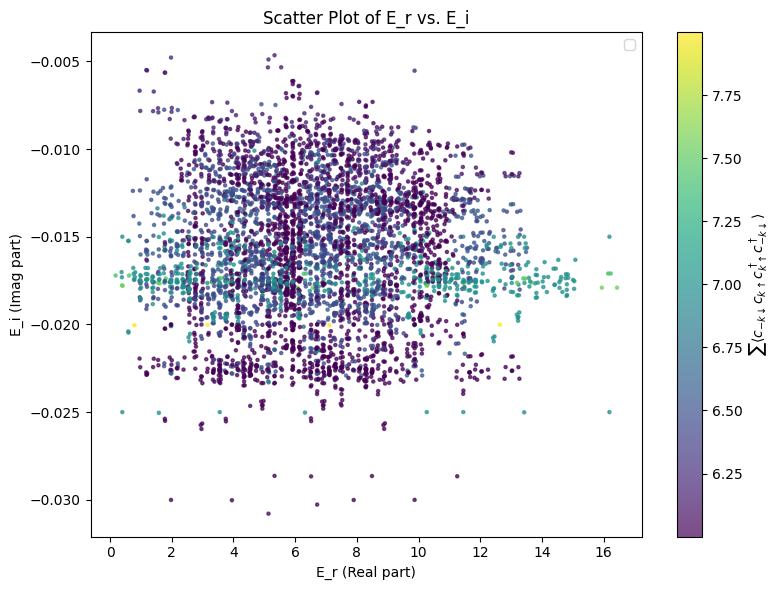

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

cbar = plt.colorbar(scatter)
cbar.set_label('$\\sum\\langle{c_{-k\\downarrow} c_{k\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

plt.xlabel("E_r (Real part)")
plt.ylabel("E_i (Imag part)")
plt.title("Scatter Plot of E_r vs. E_i")

plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()